<a href="https://colab.research.google.com/github/vsnaresh111/portfolio/blob/main/Copy_of_Europe.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tenseal


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 33.1 MB/s eta 0:00:00


In [ ]:

import torch
import tenseal as ts
import pandas as pd
import random
from time import time
# those are optional and are not necessary for training
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
from google.colab import drive


In [ ]:
torch.random.manual_seed(73)
random.seed(73)

In [ ]:
def split_train_test(x, y, test_ratio=0.90):
    idxs = [i for i in range(len(x))]
    random.shuffle(idxs)
    # delimiter between test and train data
    delim = int(len(x) * test_ratio)
    test_idxs, train_idxs = idxs[:delim], idxs[delim:]
    return x[train_idxs], y[train_idxs], x[test_idxs], y[test_idxs]


def europe_credit_data():
   drive.mount('/content/drive')
   data =  pd.read_csv('/content/drive/My Drive/Colab Notebooks/Europe/europe_csv.csv', delimiter=',')
   #Accuracy:91%
   # extract labels
   y = torch.tensor(data["output"].values).float().unsqueeze(1)
   data = data.drop("output", 'columns')
   # standardize data
   data = (data - data.mean()) / data.std()
   x = torch.tensor(data.values).float()
   return split_train_test(x, y)

# You can use whatever data you want without modification to the tutorial
# x_train, y_train, x_test, y_test = random_data()
x_train, y_train, x_test, y_test = europe_credit_data()
'''
print("############# Data summary #############")
print(f"x_train has shape: {x_train.shape}")
print(f"y_train has shape: {y_train.shape}")
print(f"x_test has shape: {x_test.shape}")
print(f"y_test has shape: {y_test.shape}")
print("#######################################")
'''

Mounted at /content/drive


<ipython-input-3-7cd253e24eb5>:16: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  data = data.drop("output", 'columns')


'\nprint("############# Data summary #############")\nprint(f"x_train has shape: {x_train.shape}")\nprint(f"y_train has shape: {y_train.shape}")\nprint(f"x_test has shape: {x_test.shape}")\nprint(f"y_test has shape: {y_test.shape}")\nprint("#######################################")\n'

In [ ]:
class LR(torch.nn.Module):

    def __init__(self, n_features):
        super(LR, self).__init__()
        self.lr = torch.nn.Linear(n_features, 1)

    def forward(self, x):
        out = torch.sigmoid(self.lr(x))
        return out

n_features = x_train.shape[1]
model = LR(n_features)
# use gradient descent with a learning_rate=1
optim = torch.optim.SGD(model.parameters(), lr=1)
# use Binary Cross Entropy Loss
criterion = torch.nn.BCELoss()


EPOCHS = 10

def train(model, optim, criterion, x, y, epochs=EPOCHS):
    for e in range(1, epochs + 1):
        optim.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optim.step()
        print(f"Loss at epoch {e}: {loss.data}")
    return model

model = train(model, optim, criterion, x_train, y_train)


def accuracy(model, x, y):
    out = model(x)
    correct = torch.abs(y - out) < 0.5
    auc=roc_auc_score(y,correct)
    print("auc",auc)
    cf_mat = confusion_matrix(y, correct)
    print('Confusion matrix')
    print(cf_mat)
    #print(f'class 0 accuracy: {cf_mat[0][0]/n_0}')
    #print(f'class 1 accuracy: {cf_mat[1][1]/n_1}')
    return correct.float().mean()

plain_accuracy = accuracy(model, x_test, y_test)
print(f"Accuracy on plain test_set: {plain_accuracy}")



Loss at epoch 1: 0.7649945616722107
Loss at epoch 2: 0.7007656097412109
Loss at epoch 3: 0.6788944005966187
Loss at epoch 4: 0.6699357032775879
Loss at epoch 5: 0.6652426719665527
Loss at epoch 6: 0.6623879075050354
Loss at epoch 7: 0.6605009436607361
Loss at epoch 8: 0.6591883897781372
Loss at epoch 9: 0.6582434773445129
Loss at epoch 10: 0.6575455665588379
auc 0.47793822393822394
Confusion matrix
[[759 991]
 [884 966]]
Accuracy on plain test_set: 0.5436111092567444


Encryption of the training_set took 15 seconds
Distribution on plain data:


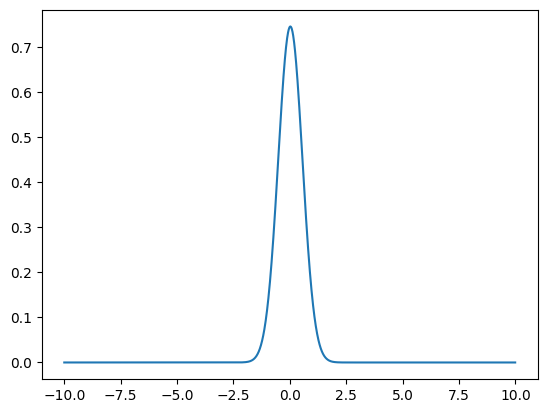

Distribution on encrypted data:


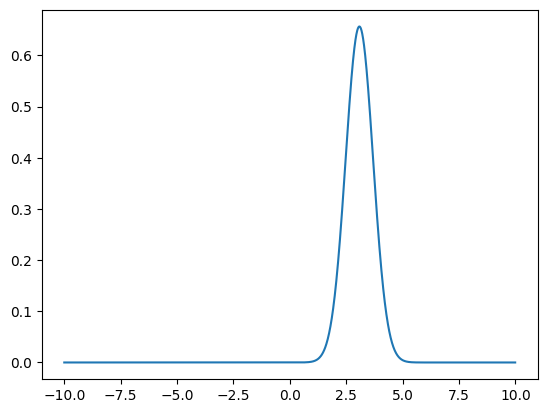

Accuracy at epoch #0 is 0.5286111235618591
Accuracy at epoch #1  is 0.4866666793823242
Accuracy at epoch #2  is 0.47999998927116394
Accuracy at epoch #3  is 0.48527777194976807
Accuracy at epoch #4  is 0.5086110830307007
Accuracy at epoch #5  is 0.5099999904632568
Accuracy at epoch #6  is 0.5138888955116272
Accuracy at epoch #7  is 0.4861111044883728
Accuracy at epoch #8  is 0.4861111044883728
Accuracy at epoch #9  is 0.4861111044883728
Accuracy at epoch #10  is 0.5138888955116272
Enc auc 1.0
Enc Confusion matrix
[[1750    0]
 [   0 1850]]

Average time per epoch: 93 seconds
Final accuracy is 0.5138888955116272
Difference between plain and encrypted accuracies: 0.029722213745117188


In [ ]:
class EncryptedLR:

    def __init__(self, torch_lr):
        # TenSEAL processes lists and not torch tensors,
        # so we take out the parameters from the PyTorch model
        self.weight = torch_lr.lr.weight.data.tolist()[0]
        self.bias = torch_lr.lr.bias.data.tolist()
        # we accumulate gradients and counts the number of iterations
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0

    def forward(self, enc_x):
        enc_out = enc_x.dot(self.weight) + self.bias
        enc_out = EncryptedLR.sigmoid3(enc_out)
        return enc_out

    def backward(self, enc_x, enc_out, enc_y):
        out_minus_y = (enc_out - enc_y)
        self._delta_w += enc_x * out_minus_y
        self._delta_b += out_minus_y
        self._count += 1

    def update_parameters(self):
        if self._count == 0:
            raise RuntimeError("You should at least run one forward iteration")
        # update weights
        # We use a small regularization term to keep the output
        # of the linear layer in the range of the sigmoid approximation
        self.weight -= self._delta_w * (1 / self._count) + self.weight * 0.05
        self.bias -= self._delta_b * (1 / self._count)
        # reset gradient accumulators and iterations count
        self._delta_w = 0
        self._delta_b = 0
        self._count = 0
    @staticmethod
    def sigmoid1(enc_x):
        # We use the polynomial approximation of degree 3
        # sigmoid(x) = 0.5 + 0.197 * x - 0.004 * x^3
        # from https://eprint.iacr.org/2018/462.pdf
        # which fits the function pretty well in the range [-5,5]
        return enc_x.polyval([ 0.125,0.5])

    @staticmethod
    def sigmoid3(enc_x):
        # We use the polynomial approximation of degree 3
        # sigmoid(x) = 0.5 + 0.197 * x - 0.004 * x^3
        # from https://eprint.iacr.org/2018/462.pdf
        # which fits the function pretty well in the range [-5,5]
        return enc_x.polyval([0.5, 0.197, 0, -0.004])
    @staticmethod
    def sigmoid5(enc_x):
        # We use the polynomial approximation of degree 3
        # sigmoid(x) = 0.5 + 0.197 * x - 0.004 * x^3
        # from https://eprint.iacr.org/2018/462.pdf
        # which fits the function pretty well in the range [-5,5]
        return enc_x.polyval([0.5, 1.73496, 0, -4.19407,0, 5.43402])

    @staticmethod
    def sigmoid7(enc_x):
        # We use the polynomial approximation of degree 3
        # sigmoid(x) = 0.5 + 0.197 * x - 0.004 * x^3
        # from https://eprint.iacr.org/2018/462.pdf
        # which fits the function pretty well in the range [-5,5]
        return enc_x.polyval([0.5, 1.73496, 0, -4.19407,0, 5.43402, 0,-2.50739])

    def plain_accuracy(self, x_test, y_test):
        # evaluate accuracy of the model on
        # the plain (x_test, y_test) dataset
        w = torch.tensor(self.weight)
        b = torch.tensor(self.bias)
        out = torch.sigmoid(x_test.matmul(w) + b).reshape(-1, 1)
        correct = torch.abs(y_test - out) < 0.5
        '''auc=roc_auc_score(y_test,correct)
        print("Enc auc",auc)
        cf_mat = confusion_matrix(y_test, correct)
        print('Enc Confusion matrix')
        print(cf_mat)'''
        return correct
        #return correct.float().mean()

    def encrypt(self, context):
        self.weight = ts.ckks_vector(context, self.weight)
        self.bias = ts.ckks_vector(context, self.bias)

    def decrypt(self):
        self.weight = self.weight.decrypt()
        self.bias = self.bias.decrypt()

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)


# parameters

poly_mod_degree = 8192
coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]
# create TenSEALContext
ctx_training = ts.context(ts.SCHEME_TYPE.CKKS, poly_mod_degree, -1, coeff_mod_bit_sizes)
ctx_training.global_scale = 2**21
ctx_training.generate_galois_keys()

t_start = time()
enc_x_train = [ts.ckks_vector(ctx_training, x.tolist()) for x in x_train]
enc_y_train = [ts.ckks_vector(ctx_training, y.tolist()) for y in y_train]
t_end = time()
print(f"Encryption of the training_set took {int(t_end - t_start)} seconds")

normal_dist = lambda x, mean, var: np.exp(- np.square(x - mean) / (2 * var)) / np.sqrt(2 * np.pi * var)

def plot_normal_dist(mean, var, rmin=-10, rmax=10):
    x = np.arange(rmin, rmax, 0.01)
    y = normal_dist(x, mean, var)
    fig = plt.plot(x, y)

# plain distribution
lr = LR(n_features)
data = lr.lr(x_test)
mean, var = map(float, [data.mean(), data.std() ** 2])
plot_normal_dist(mean, var)
print("Distribution on plain data:")
plt.show()

# encrypted distribution
def encrypted_out_distribution(eelr, enc_x_test):
    w = eelr.weight
    b = eelr.bias
    data = []
    for enc_x in enc_x_test:
        enc_out = enc_x.dot(w) + b
        data.append(enc_out.decrypt())
    data = torch.tensor(data)
    mean, var = map(float, [data.mean(), data.std() ** 2])
    plot_normal_dist(mean, var)
    print("Distribution on encrypted data:")
    plt.show()

eelr = EncryptedLR(lr)
eelr.encrypt(ctx_training)
encrypted_out_distribution(eelr, enc_x_train)

eelr = EncryptedLR(LR(n_features))
correct=eelr.plain_accuracy(x_test, y_test)
#accuracy = eelr.plain_accuracy(x_test, y_test)
print(f"Accuracy at epoch #0 is {correct.float().mean()}")


times = []
for epoch in range(EPOCHS):
    eelr.encrypt(ctx_training)

    # if you want to keep an eye on the distribution to make sure
    # the function approxiamation is still working fine
    # WARNING: this operation is time consuming
    # encrypted_out_distribution(eelr, enc_x_train)

    t_start = time()
    for enc_x, enc_y in zip(enc_x_train, enc_y_train):
        enc_out = eelr.forward(enc_x)
        eelr.backward(enc_x, enc_out, enc_y)
    eelr.update_parameters()
    t_end = time()
    times.append(t_end - t_start)

    eelr.decrypt()
    #accuracy = eelr.plain_accuracy(x_test, y_test)
    #print(f"Accuracy at epoch #{epoch + 1} is {accuracy}")
    correct=eelr.plain_accuracy(x_test, y_test)
    #accuracy = eelr.plain_accuracy(x_test, y_test)
    print(f"Accuracy at epoch #{epoch + 1}  is {correct.float().mean()}")

accuracy=correct.float().mean()
auc=roc_auc_score(y_test,correct)
print("Enc auc",auc)
cf_mat = confusion_matrix(y_test, correct)
print('Enc Confusion matrix')
print(cf_mat)

print(f"\nAverage time per epoch: {int(sum(times) / len(times))} seconds")

print(f"Final accuracy is {accuracy}")

diff_accuracy = plain_accuracy - accuracy
print(f"Difference between plain and encrypted accuracies: {diff_accuracy}")
if diff_accuracy < 0:
    print("Oh! We got a better accuracy when training on encrypted data! The noise was on our side...")